### What is Arithmetic Compression?

Arithmetic compression is an entropy encoding technique used for lossless data compression. Unlike other compression methods that assign fixed-length codes to symbols (like Huffman coding), arithmetic coding represents an entire sequence of symbols as a single fractional number within a specified interval. This allows for more efficient compression, especially for data with skewed symbol probabilities, as it can assign fractional bits per symbol.

### Core Principles:

1.  **Interval Representation:** The core idea is to represent a message as a sub-interval within the initial interval of `[0, 1)`. Each symbol in the input sequence progressively narrows this interval.
2.  **Symbol Probabilities:** Before encoding begins, the probabilities of each unique symbol appearing in the data are determined. These probabilities are crucial for defining the size of each symbol's sub-interval.
3.  **Dynamic Interval Subdivision:** As each symbol is processed, the current interval is subdivided based on the symbol's probability. The lower bound of the interval is updated, and the new range (upper bound - lower bound) becomes the basis for the next subdivision.
4.  **Final Code:** After encoding all symbols, the final interval represents the entire message. Any number chosen from within this final interval (e.g., the smallest number) can be transmitted as the compressed code. The precision required for this number depends on the length of the message and the accuracy of the probability model.

### Advantages over other compression methods:

*   **Higher Compression Ratios:** Arithmetic coding often achieves better compression ratios than Huffman coding, especially when dealing with sources that have highly skewed probability distributions or when symbols have very low probabilities, allowing for effective fractional bit coding.
*   **Adaptability:** It can easily adapt to changing symbol probabilities within a data stream (adaptive arithmetic coding), which is beneficial for dynamic data types.
*   **No Fixed Codebook:** Unlike Huffman coding, it doesn't require building a codebook, which can be an overhead for small files or when probabilities change frequently.

### Applications in Multimedia Analytics:

In multimedia analytics, efficient data storage and transmission are paramount due to the large file sizes involved (images, audio, video). Arithmetic compression plays a vital role:

*   **Image Compression:** Used in standards like JPEG 2000, where it can provide better compression efficiency and features like scalable compression.
*   **Audio Compression:** Can be employed in various audio codecs, particularly for achieving higher compression rates for speech or music data with repetitive patterns.
*   **Video Compression:** While not the primary compression method for entire video streams, its principles or variations are often used in components of video codecs for encoding residual errors or specific data types, contributing to overall efficiency.
*   **Efficient Data Storage:** By significantly reducing file sizes, arithmetic compression minimizes storage requirements, leading to lower costs and faster data retrieval in large multimedia databases.
*   **Faster Transmission:** Smaller file sizes mean less bandwidth is needed for transmission, resulting in faster download times and more efficient streaming of multimedia content over networks.

### Mathematical Calculation Steps of Arithmetic Compression

Arithmetic compression is a form of entropy encoding used in lossless data compression. It works by representing an entire message as a single fraction within the unit interval `[0, 1)`, where the size of the interval corresponds to the probability of the message.

#### 1. Probability Distribution and Cumulative Ranges

Before encoding or decoding, it is essential to define a probability distribution for all possible symbols in the alphabet. Each symbol `s` is assigned a probability `P(s)`. From these individual probabilities, cumulative probability ranges are derived. For each symbol `s`:

*   **Cumulative Low (CLow(s))**: The sum of probabilities of all symbols that lexicographically precede `s`.
*   **Cumulative High (CHigh(s))**: The sum of probabilities of `s` and all symbols that lexicographically precede `s`. This is equivalent to `CLow(s) + P(s)`.

These ranges divide the `[0, 1)` interval based on the likelihood of each symbol. For example, if we have symbols A (P=0.2), B (P=0.3), C (P=0.5):

*   A: CLow(A) = 0.0, CHigh(A) = 0.2
*   B: CLow(B) = 0.2, CHigh(B) = 0.5
*   C: CLow(C) = 0.5, CHigh(C) = 1.0

#### 2. Encoding Logic

The encoding process iteratively subdivides the current interval based on the symbols in the input message.

*   **Initialization**: Begin with the initial interval `[low, high) = [0.0, 1.0)`.

*   **For each symbol in the input message**:
    *   **Calculate Current Range**: Determine the width of the current interval: `current_range = high - low`.
    *   **Update High Bound**: The new `high` value is calculated as `low + current_range * CHigh(symbol)`. This shrinks the upper bound of the interval to reflect the symbol's contribution.
    *   **Update Low Bound**: The new `low` value is calculated as `low + current_range * CLow(symbol)`. This expands the lower bound of the interval to reflect the symbol's contribution.
    *   Essentially, the current interval `[low, high)` is scaled down to a sub-interval determined by the cumulative probability range of the current symbol.

*   **Final Encoded Value**: After processing all symbols in the message, the final `[low, high)` interval represents the entire message. Any number within this final interval can be chosen as the encoded value. Typically, a value like `(low + high) / 2` or `low` (rounded appropriately to prevent precision loss) is selected.

#### 3. Decoding Logic

Decoding reverses the encoding process, using the known probability model and the encoded value to reconstruct the original message.

*   **Initialization**: Start with the initial interval `[low, high) = [0.0, 1.0)`. The `encoded_value` is given.

*   **Iterative Decoding**: Repeatedly perform the following steps until the entire message is decoded (or a termination symbol is found):
    *   **Calculate Current Range**: `current_range = high - low`.
    *   **Identify Symbol**: Determine which symbol's cumulative probability range contains the `encoded_value` within the *current* interval. This is done by checking the condition:
        `low + current_range * CLow(symbol) <= encoded_value < low + current_range * CHigh(symbol)`
        for each symbol in the alphabet. The symbol `s` for which this condition is true is the next decoded symbol.
    *   **Append Symbol**: Add the identified symbol to the decoded message.
    *   **Update Interval**: Just like in encoding, update `low` and `high` for the next iteration using the identified symbol's cumulative range:
        *   `new_high = low + current_range * CHigh(identified_symbol)`
        *   `new_low = low + current_range * CLow(identified_symbol)`
        Then, set `low = new_low` and `high = new_high`.
    *   **Scaling/Adjustment**: The `encoded_value` itself doesn't need to be explicitly scaled or adjusted with respect to the new interval; rather, the process implicitly tracks its position relative to the shrinking interval bounds `low` and `high` in each step. The core idea is that the *relative position* of the encoded value within the current `[low, high)` interval indicates which sub-interval it falls into.

#### Role of Cumulative Probabilities

Cumulative probabilities are critical because they define the unique 'address' or sub-interval for each symbol. This allows the arithmetic coder to deterministically narrow down the interval for both encoding and decoding, ensuring that the same sequence of symbols leads to the same final interval, and vice-versa. The iterative subdivision of the unit interval, guided by these cumulative probabilities, is the core mathematical principle behind arithmetic compression's effectiveness.

### 1. & 2. & 3. Choose a short, simple message, define the alphabet, assign probabilities, and calculate cumulative ranges.

Let's choose the message **'BAC'**.

**Alphabet:** {'A', 'B', 'C'}

**Assigned Probabilities:**
*   P('A') = 0.2
*   P('B') = 0.3
*   P('C') = 0.5

(Note: The sum of probabilities is 0.2 + 0.3 + 0.5 = 1.0)

**Cumulative Low and High Ranges (CLow, CHigh):**
These ranges define the sub-interval each symbol occupies within a larger interval.

*   For 'A': CLow('A') = 0.0, CHigh('A') = 0.2
*   For 'B': CLow('B') = 0.2, CHigh('B') = 0.2 + 0.3 = 0.5
*   For 'C': CLow('C') = 0.5, CHigh('C') = 0.5 + 0.5 = 1.0

So, the cumulative ranges are:
*   'A': [0.0, 0.2)
*   'B': [0.2, 0.5)
*   'C': [0.5, 1.0)

### 4. & 5. Initialize the encoding interval and perform encoding for each symbol.

**Initial Encoding Interval:**
`low = 0.0`
`high = 1.0`

**Message to Encode: 'BAC'**

---

#### Encoding Symbol 1: 'B'
*   **Current Interval:** `[0.0, 1.0)`
*   `CLow('B') = 0.2`
*   `CHigh('B') = 0.5`

1.  **Calculate `current_range`:**
    `current_range = high - low = 1.0 - 0.0 = 1.0`

2.  **Update `high`:**
    `high = low + current_range * CHigh('B')`
    `high = 0.0 + 1.0 * 0.5 = 0.5`

3.  **Update `low`:**
    `low = low + current_range * CLow('B')`
    `low = 0.0 + 1.0 * 0.2 = 0.2`

4.  **New Interval for 'B':** `[0.2, 0.5)`

---

#### Encoding Symbol 2: 'A'
*   **Current Interval:** `[0.2, 0.5)`
*   `CLow('A') = 0.0`
*   `CHigh('A') = 0.2`

1.  **Calculate `current_range`:**
    `current_range = high - low = 0.5 - 0.2 = 0.3`

2.  **Update `high`:**
    `high = low + current_range * CHigh('A')`
    `high = 0.2 + 0.3 * 0.2 = 0.2 + 0.06 = 0.26`

3.  **Update `low`:**
    `low = low + current_range * CLow('A')`
    `low = 0.2 + 0.3 * 0.0 = 0.2 + 0.0 = 0.2`

4.  **New Interval for 'A':** `[0.2, 0.26)`

---

#### Encoding Symbol 3: 'C'
*   **Current Interval:** `[0.2, 0.26)`
*   `CLow('C') = 0.5`
*   `CHigh('C') = 1.0`

1.  **Calculate `current_range`:**
    `current_range = high - low = 0.26 - 0.2 = 0.06`

2.  **Update `high`:**
    `high = low + current_range * CHigh('C')`
    `high = 0.2 + 0.06 * 1.0 = 0.2 + 0.06 = 0.26`

3.  **Update `low`:**
    `low = low + current_range * CLow('C')`
    `low = 0.2 + 0.06 * 0.5 = 0.2 + 0.03 = 0.23`

4.  **New Interval for 'C':** `[0.23, 0.26)`

---

### 6. Final Encoded Interval and Possible Value

After processing all symbols, the final encoded interval for the message 'BAC' is `[0.23, 0.26)`.

Any number within this interval can represent the encoded message. For instance, a possible encoded value could be **0.24**.

### 4. & 5. Initialize the encoding interval and perform encoding for each symbol.

**Initial Encoding Interval:**
`low = 0.0`
`high = 1.0`

**Message to Encode: 'BAC'**

---

#### Encoding Symbol 1: 'B'
*   **Current Interval:** `[0.0, 1.0)`
*   `CLow('B') = 0.2`
*   `CHigh('B') = 0.5`

1.  **Calculate `current_range`:**
    `current_range = high - low = 1.0 - 0.0 = 1.0`

2.  **Update `high`:**
    `high = low + current_range * CHigh('B')`
    `high = 0.0 + 1.0 * 0.5 = 0.5`

3.  **Update `low`:**
    `low = low + current_range * CLow('B')`
    `low = 0.0 + 1.0 * 0.2 = 0.2`

4.  **New Interval for 'B':** `[0.2, 0.5)`

---

#### Encoding Symbol 2: 'A'
*   **Current Interval:** `[0.2, 0.5)`
*   `CLow('A') = 0.0`
*   `CHigh('A') = 0.2`

1.  **Calculate `current_range`:**
    `current_range = high - low = 0.5 - 0.2 = 0.3`

2.  **Update `high`:**
    `high = low + current_range * CHigh('A')`
    `high = 0.2 + 0.3 * 0.2 = 0.2 + 0.06 = 0.26`

3.  **Update `low`:**
    `low = low + current_range * CLow('A')`
    `low = 0.2 + 0.3 * 0.0 = 0.2 + 0.0 = 0.2`

4.  **New Interval for 'A':** `[0.2, 0.26)`

---

#### Encoding Symbol 3: 'C'
*   **Current Interval:** `[0.2, 0.26)`
*   `CLow('C') = 0.5`
*   `CHigh('C') = 1.0`

1.  **Calculate `current_range`:**
    `current_range = high - low = 0.26 - 0.2 = 0.06`

2.  **Update `high`:**
    `high = low + current_range * CHigh('C')`
    `high = 0.2 + 0.06 * 1.0 = 0.2 + 0.06 = 0.26`

3.  **Update `low`:**
    `low = low + current_range * CLow('C')`
    `low = 0.2 + 0.06 * 0.5 = 0.2 + 0.03 = 0.23`

4.  **New Interval for 'C':** `[0.23, 0.26)`

---

### 6. Final Encoded Interval and Possible Value

After processing all symbols, the final encoded interval for the message 'BAC' is `[0.23, 0.26)`.

Any number within this interval can represent the encoded message. For instance, a possible encoded value could be **0.24**.


In [1]:
def arithmetic_encode(message, prob_model):
    low = 0.0
    high = 1.0

    for symbol in message:
        current_range = high - low
        # Update high based on the symbol's high probability range
        high = low + current_range * prob_model[symbol]['high']
        # Update low based on the symbol's low probability range
        low = low + current_range * prob_model[symbol]['low']

    # Return the midpoint of the final [low, high) interval
    encoded_value = (low + high) / 2
    return encoded_value

print("The arithmetic_encode function has been defined.")

The arithmetic_encode function has been defined.


In [2]:
prob_model = {
    'A': {'prob': 0.2, 'low': 0.0, 'high': 0.2},
    'B': {'prob': 0.3, 'low': 0.2, 'high': 0.5},
    'C': {'prob': 0.5, 'low': 0.5, 'high': 1.0}
}

message = 'BAC'

encoded_result = arithmetic_encode(message, prob_model)

print(f"Original Message: {message}")
print(f"Encoded Value: {encoded_result}")

Original Message: BAC
Encoded Value: 0.245


In [3]:
def arithmetic_decode(encoded_value, prob_model, message_length):
    low = 0.0
    high = 1.0
    decoded_message = []

    for _ in range(message_length):
        current_range = high - low

        # Find the symbol that matches the encoded_value within the current interval
        for symbol, data in prob_model.items():
            symbol_low = low + current_range * data['low']
            symbol_high = low + current_range * data['high']

            if symbol_low <= encoded_value < symbol_high:
                decoded_message.append(symbol)
                # Update the interval for the next symbol
                low = symbol_low
                high = symbol_high
                break # Move to the next symbol in the encoded message

    return ''.join(decoded_message)

print("The arithmetic_decode function has been defined.")

The arithmetic_decode function has been defined.


In [4]:
decoded_message = arithmetic_decode(encoded_result, prob_model, len(message))

print(f"Encoded Value: {encoded_result}")
print(f"Decoded Message: {decoded_message}")
print(f"Original Message: {message}")

if decoded_message == message:
    print("Decoding successful! The decoded message matches the original message.")
else:
    print("Decoding failed. The decoded message does not match the original message.")

Encoded Value: 0.245
Decoded Message: BAC
Original Message: BAC
Decoding successful! The decoded message matches the original message.


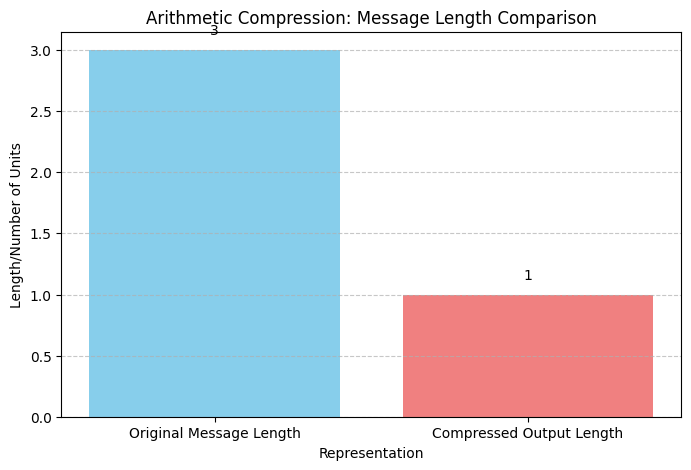

In [5]:
import matplotlib.pyplot as plt

# Get the length of the original message
original_length = len(message)

# For compressed output, consider it as 1 as it's a single number
compressed_length = 1

# Data for plotting
labels = ['Original Message Length', 'Compressed Output Length']
lengths = [original_length, compressed_length]

# Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, lengths, color=['skyblue', 'lightcoral'])

# Add title and labels
plt.title('Arithmetic Compression: Message Length Comparison')
plt.xlabel('Representation')
plt.ylabel('Length/Number of Units')

# Add value labels on top of bars
for i, v in enumerate(lengths):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
